
--- Logistic Regression ---
Training Accuracy: 92.85%
Test Accuracy: 92.85%
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       784
           1       0.93      0.95      0.94      1007

    accuracy                           0.93      1791
   macro avg       0.93      0.93      0.93      1791
weighted avg       0.93      0.93      0.93      1791


--- Random Forest ---
Training Accuracy: 99.05%
Test Accuracy: 96.43%
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       784
           1       0.96      0.98      0.97      1007

    accuracy                           0.96      1791
   macro avg       0.96      0.96      0.96      1791
weighted avg       0.96      0.96      0.96      1791


--- XGBoost ---
Training Accuracy: 98.62%
Test Accuracy: 96.98%
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       784
           1       0.97 

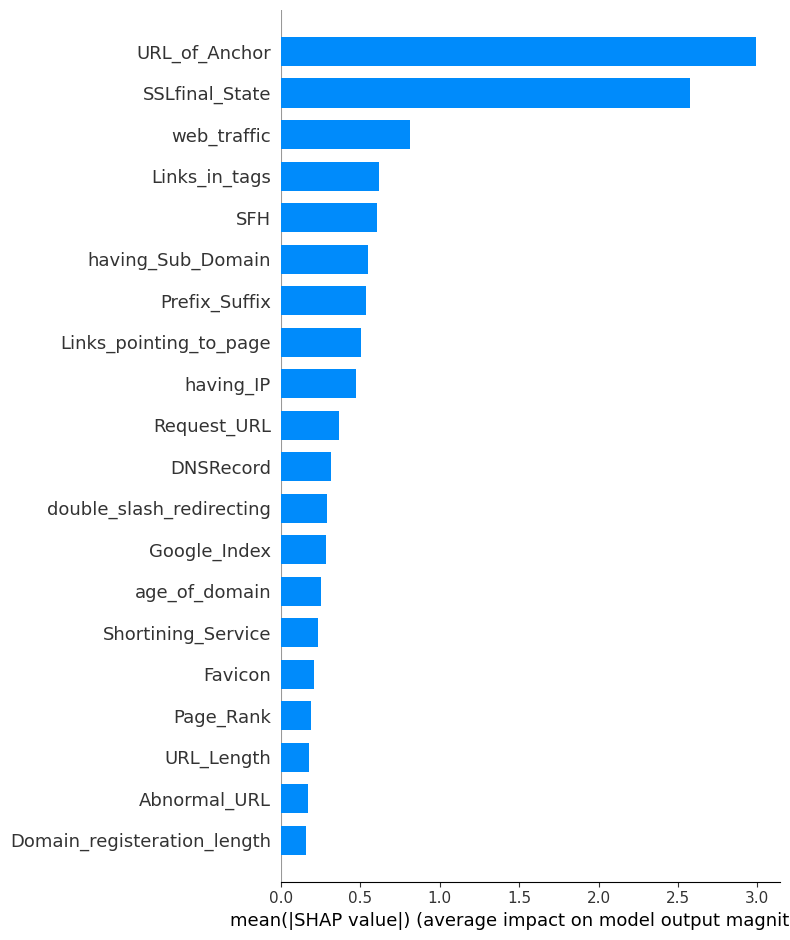

In [ ]:
# 1. Data Loading
import pandas as pd
from sklearn.model_selection import train_test_split

# Load training dataset
train_path = '/kaggle/input/phishing-dataset/Phising_Training_Dataset.csv'
df = pd.read_csv(train_path)

# Drop 'key' column if exists
if 'key' in df.columns:
    df.drop('key', axis=1, inplace=True)

# Separate features and target
df['Result'] = df['Result'].replace(-1, 0)
X = df.drop('Result', axis=1)
y = df['Result'].astype(int)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Standardization
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler
joblib.dump(scaler, "standard_scaler.pkl")

# 3. Train Logistic Regression
print("\n--- Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Training Accuracy: {:.2f}%".format(lr_model.score(X_train_scaled, y_train) * 100))
print("Test Accuracy: {:.2f}%".format(acc_lr * 100))
print(classification_report(y_test, y_pred_lr))

# 4. Train Random Forest
print("\n--- Random Forest ---")
rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Training Accuracy: {:.2f}%".format(rf_model.score(X_train_scaled, y_train) * 100))
print("Test Accuracy: {:.2f}%".format(acc_rf * 100))
print(classification_report(y_test, y_pred_rf))

# 5. Train XGBoost
print("\n--- XGBoost ---")
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("Training Accuracy: {:.2f}%".format(xgb_model.score(X_train_scaled, y_train) * 100))
print("Test Accuracy: {:.2f}%".format(acc_xgb * 100))
print(classification_report(y_test, y_pred_xgb))

# 6. Save Best Performing Model
accuracies = {
    'logistic_regression': acc_lr,
    'random_forest': acc_rf,
    'xgboost': acc_xgb
}
best_model_name = max(accuracies, key=accuracies.get)

if best_model_name == 'logistic_regression':
    joblib.dump(lr_model, 'best_model.pkl')
elif best_model_name == 'random_forest':
    joblib.dump(rf_model, 'best_model.pkl')
else:
    joblib.dump(xgb_model, 'best_model.pkl')

print(f"\nBest Model ({best_model_name}) saved as best_model.pkl with Accuracy: {accuracies[best_model_name]*100:.2f}%")

# 7. Explainable AI - SHAP
import shap
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_scaled[:100])
shap.summary_plot(shap_values, X_test.iloc[:100], plot_type="bar")


In [ ]:
!pip freeze>req.txt

In [ ]:
!python --version

Python 3.10.12
